In [28]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

def scat(x, y, c,marker):
    return ax.scatter(x, y*100, c=c, ls='-', cmap=cmap, norm=norm, s=30, marker=marker
                     )
import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein
sys.path.append('../survey_design/')
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [30]:
path = '../survey_design/telescope_and_science_metrics/'

In [31]:
survey_design_bright_bao = load(path + 'survey_design_Bright_desilike_bao_rsd_forecast.pkl')
survey_design_grey_bao = load(path + 'survey_design_Grey_desilike_bao_rsd_forecast.pkl')
survey_design_dark_qso_bao = load(path + 'survey_design_Dark_qso_only_bao_rsd_fnl_forecast.pkl')
survey_design_grey_MagMax = load(path + 'survey_design_Grey_MagMax_bao_rsd_forecast.pkl')

BG_bright = 2905.251641137855
BG_bright  mag = 20.70

BG_grey = 4250.929978118162
BG_grey  mag = 21.60

LRG = 2508.807439824945
LRG  mag = 22.95

ELG = 21418.75027367868
ELG  mag = 25.19

31083.739332759644
MagMax = 30310.11904761905
MagMax  mag = 21.83



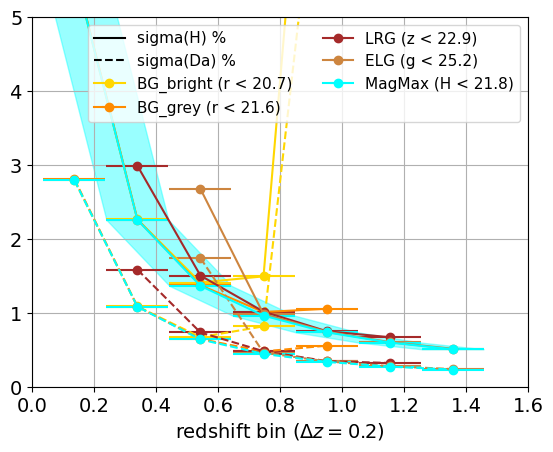

In [48]:
n=0
for k, tracer in enumerate(['BG_bright', 'BG_grey', 'LRG','ELG', 'MagMax',]):

    if tracer == 'BG_bright':
        survey = survey_design_bright_bao 
        i =7
        #plt.errorbar(survey_design_bright['per_tracer_forecasts'][tracer+'_list_zbin_rsd'][i], survey_design_bright['per_tracer_forecasts'][tracer+'_list_sigma_rsd'][i], xerr=0.1)
    if tracer == 'BG_grey':
        survey = survey_design_grey_bao 
        i=2

    if tracer == 'LRG':
        survey = survey_design_grey_bao 
        i=-1 #22.8

    if tracer == 'ELG':
        survey = survey_design_grey_bao 
        i=-2 #25.3

    if tracer == 'MagMax':
        survey = survey_design_grey_MagMax
        i=12
    if tracer == 'QSO_qlf':
        survey = survey_design_dark_qso_bao 
        i=18

    if tracer!='MagMax' and tracer!='QSO_qlf':
        n+=survey['config_survey'][tracer+'_target_density'][i]

    if tracer=='MagMax': 
        print(n)
    
    print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])


    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]
    
    mag_Str = np.array(survey['config_survey']['limiting_mag_band'])[mask_color][0]
    #print(survey['config_survey'][tracer+'_spec_density'][i])

    max_mag = survey['config_survey'][tracer + '_mag_centers'][i]

    print(tracer, f' mag = {max_mag:.2F}')
    print()
    label = tracer + f' ({mag_Str} < {max_mag:.1f})'
    if tracer!='MagMax':
        x, y = survey['per_tracer_forecasts'][tracer+'_list_zbin_Da'][i], 100*np.array(survey['per_tracer_forecasts'][tracer+'_list_sigma_H'][i])
        plt.errorbar(np.array(x), np.array(y), xerr=0.1, label = label,
                     color = color, 
                     marker='o', fmt='-')

        x, y = survey['per_tracer_forecasts'][tracer+'_list_zbin_Da'][i], 100*np.array(survey['per_tracer_forecasts'][tracer+'_list_sigma_Da'][i])
        plt.errorbar(np.array(x), np.array(y), xerr=0.1, 
                     color = color, 
                     marker='o', fmt='--')

    if tracer=='MagMax':
        x = np.array(
                survey['per_tracer_forecasts'][tracer + '_list_zbin_H'][i]
            )
        y = 100 * np.array(
                survey['per_tracer_forecasts'][tracer + '_list_sigma_H'][i]
            )

            
        mask = y < 10000000
        
        x_plot = x[mask]
        y_plot = y[mask]
        
        xerr = 0.1
        
        plt.errorbar(
            x_plot, y_plot,
            xerr=xerr,
            label=label,
            color=color,
            marker='o',
            #fmt='-'
        )
        
        plt.fill_betweenx(
            y_plot,
            x_plot - xerr,
            x_plot + xerr,
            color=color,
            alpha=0.4
        )

    if tracer=='MagMax':
        x = np.array(
                survey['per_tracer_forecasts'][tracer + '_list_zbin_Da'][i]
            )
        y = 100 * np.array(
                survey['per_tracer_forecasts'][tracer + '_list_sigma_Da'][i]
            )

            
        mask = y < 10000000
        
        x_plot = x[mask]
        y_plot = y[mask]
        
        xerr = 0.1
        
        plt.errorbar(
            x_plot, y_plot,
            xerr=xerr,

            color=color, fmt='--',
            marker='o',
            #fmt='-'
        )


            
        #plt.plot(np.array(x)[y < 10], np.array(y)[y < 10],
                     #color = color, 
                     #marker='x',)
        

    plt.xlim(0, 1.6)
    plt.ylim(0, 5)
#plt.ylabel(r'$\sigma(f\sigma_8) (\%)$', fontsize=14)
plt.xlabel(r'redshift bin ($\Delta z = 0.2)$', fontsize=14)
plt.tick_params(axis='both', labelsize=14)
plt.plot([], [], '-k', label = 'sigma(H) %')
plt.plot([], [], '--k', label = 'sigma(Da) %')
plt.legend(fontsize=11, ncols=2)
plt.grid()

#plt.savefig(f'../figures_for_paper/desilike_magmax_rsd_redshift_bins.png', dpi = 200, bbox_inches='tight',)